<a href="https://colab.research.google.com/github/rifat01-rahman/Timse_Series_forecasting-/blob/main/Chapter_1_Fundamentals_of_Risk_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Relationship between Risk and Return

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import plotly
import warnings

warnings.filterwarnings('ignore')


n_assets = 5
n_simulation = 500

returns = np.random.randn(n_assets, n_simulation)

returns = pd.DataFrame(
    returns.T,
    columns=[f'Asset_{i}' for i in range(1, 6)]
)


rand = np.random.rand(n_assets)
weights = rand / sum(rand)


def port_return(returns, weights):

    rets = np.mean(returns, axis=0)

    cov = np.cov(returns.T, ddof=1)

    portfolio_return = np.dot(weights, rets)

    portfolio_std = np.sqrt(
        weights @ cov @ weights
    )

    return portfolio_return, portfolio_std

In [ ]:
returns

,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5
0,0.291417,1.037511,0.950566,-1.163986,2.299858
1,2.059426,0.065052,-0.245316,-0.709714,0.157693
2,0.783868,-0.053686,-0.868447,-0.204372,0.873288
3,0.396533,-1.702424,0.570548,0.174325,0.788715
4,0.947733,-0.627330,-0.092284,-1.760440,-0.572730
...,...,...,...,...,...
495,0.566445,-0.914881,1.060504,1.691790,0.067073
496,-0.552824,-1.305322,-1.269443,3.569408,-0.512682
497,-0.457273,-0.149473,0.784244,-0.066369,0.408504
498,-0.388334,-1.011810,-0.557303,1.794601,0.100410


In [ ]:
portfolio_returns, portfolio_std_dev = port_return(returns)

In [ ]:
print(portfolio_returns)
print(portfolio_std_dev)

0.024957173198441922
0.5172801523337629


In [ ]:
portfolio = []

for i in range(500):

    weights = np.random.random(n_assets)
    weights = weights / weights.sum()

    simulated_returns = np.random.randn(100, n_assets)

    portfolio_return, portfolio_std = port_return(
        simulated_returns,
        weights
    )

    portfolio.append([portfolio_return, portfolio_std])

portfolio = np.array(portfolio)

In [ ]:
portfolio

array([[ 1.42622028e-03,  5.09034517e-01],
       [ 3.79753495e-03,  5.43909857e-01],
       [-6.21267426e-02,  4.64144798e-01],
       [-1.09439105e-02,  4.92863659e-01],
       [-9.13978083e-03,  4.87993515e-01],
       [-5.51625098e-02,  4.82749834e-01],
       [ 9.33954216e-03,  5.08437209e-01],
       [ 2.33593328e-02,  5.49549714e-01],
       [-1.03080585e-01,  6.42532623e-01],
       [-2.08330245e-02,  4.21742455e-01],
       [-1.56776908e-02,  4.75917858e-01],
       [-9.23994959e-03,  5.08041416e-01],
       [ 5.46176590e-02,  4.82286695e-01],
       [ 4.62627364e-02,  4.53055454e-01],
       [ 1.25764507e-02,  5.09118206e-01],
       [ 4.45301863e-02,  4.72127073e-01],
       [-1.28768963e-02,  4.88686095e-01],
       [ 1.16010902e-02,  5.05903203e-01],
       [-1.68956979e-02,  5.16371865e-01],
       [-1.82311395e-01,  5.57819286e-01],
       [-2.23697327e-02,  5.80606164e-01],
       [ 3.80113485e-02,  5.81197562e-01],
       [ 1.13597770e-01,  5.07464657e-01],
       [-3.

In [ ]:
best_fit = sm.OLS(
    portfolio[:, 1],
    sm.add_constant(portfolio[:, 0])
).fit().fittedvalues

In [ ]:
fig = go.Figure()

# 1. Plot the simulated portfolios
fig.add_trace(
    go.Scatter(
        name='Risk-Return Relationship',
        x=portfolio[:, 0],      # Portfolio Return
        y=portfolio[:, 1],      # Portfolio Standard Deviation
        mode='markers'
    )
)

# 2. Plot the OLS best-fit line
fig.add_trace(
    go.Scatter(
        name='Best Fit Line',
        x=portfolio[:, 0],      # Portfolio Return
        y=best_fit,             # Predicted Risk from OLS
        mode='lines'
    )
)

# 3. Add labels and set figure size
fig.update_layout(
    xaxis_title='Return',
    yaxis_title='Standard Deviation',
    width=900,
    height=470
)

# 4. Display the chart
fig.show()

## MA and AR model for Finance data

In [ ]:
import datetime
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

In [ ]:
os.makedirs('images', exist_ok=True)

In [ ]:
# ---- 1. Fetch data ----
ticker = ['AAPL', 'MSFT']
start = datetime.datetime(2019, 1, 1)
end = datetime.datetime(2021, 1, 1)

stock_prices = yf.download(ticker, start=start, end=end, interval='1d').Close
stock_prices = stock_prices.dropna()


/tmp/ipykernel_1088/3402622782.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_prices = yf.download(ticker, start=start, end=end, interval='1d').Close
[*********************100%***********************]  2 of 2 completed


In [ ]:
stock_prices.head ()

Ticker,AAPL,MSFT
Date,,
2019-01-02,37.436909,94.016144
2019-01-03,33.707924,90.557465
2019-01-04,35.146893,94.769234
2019-01-07,35.068653,94.890106
2019-01-08,35.737175,95.578133


In [ ]:
# ---- 2. ADF test on raw prices ----
for i in ticker:
    stat_test = adfuller(stock_prices[i])[0:2]
    print("The ADF test statistic and p-value of {} are {}".format(i, stat_test))

The ADF test statistic and p-value of AAPL are (0.31939780496021997, 0.978217150800129)
The ADF test statistic and p-value of MSFT are (-0.744506642142996, 0.8348821500664445)


/tmp/ipykernel_1088/2536361295.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat_test = adfuller(stock_prices[i])[0:2]
/tmp/ipykernel_1088/2536361295.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat_test = adfuller(stock_prices[i])[0:2]


In [ ]:
# ---- 3. Difference the series ----
diff_stock_prices = stock_prices.diff().dropna()

In [ ]:
# ---- 4. Train/test split (95/5) ----
split = int(len(diff_stock_prices['AAPL'].values) * 0.95)

diff_train_aapl = diff_stock_prices['AAPL'].iloc[:split]
diff_test_aapl = diff_stock_prices['AAPL'].iloc[split:]
diff_train_msft = diff_stock_prices['MSFT'].iloc[:split]
diff_test_msft = diff_stock_prices['MSFT'].iloc[split:]


In [ ]:
diff_train_aapl.to_csv('diff_train_aapl.csv')
diff_test_aapl.to_csv('diff_test_aapl.csv')
diff_train_msft.to_csv('diff_train_msft.csv')
diff_test_msft.to_csv('diff_test_msft.csv')


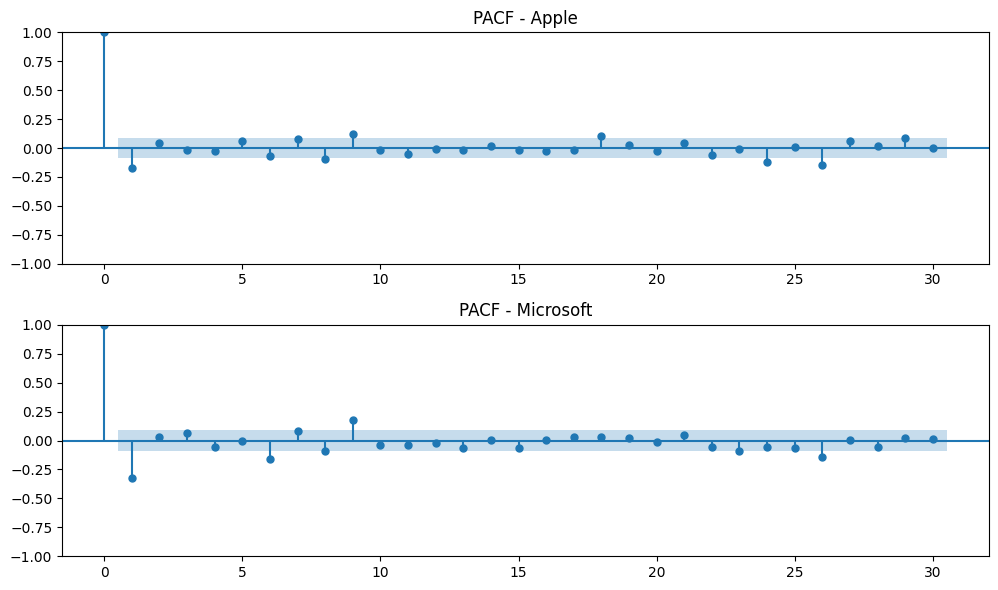

In [ ]:
# ---- 5. ACF plots ----
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
sm.graphics.tsa.plot_pacf(diff_train_aapl, lags=30, ax=ax[0])
ax[0].set_title('PACF - Apple')
sm.graphics.tsa.plot_pacf(diff_train_msft, lags=30, ax=ax[1])
ax[1].set_title('PACF - Microsoft')
plt.tight_layout()
plt.savefig('images/acf_ma.png')
plt.show()

In [ ]:
# ---- 6. Fit MA model ----
# order = (p=0, d=0, q) since data is already differenced manually
p_aapl = 27    # set based on where ACF cuts off
p_msft = 25

# Reset index to avoid frequency issues with forecast()
diff_train_aapl_idx = diff_train_aapl.reset_index(drop=True)
diff_train_msft_idx = diff_train_msft.reset_index(drop=True)

ma_model_aapl = ARIMA(diff_train_aapl_idx, order=(p_aapl, 0, 0)).fit()
ma_model_msft = ARIMA(diff_train_msft_idx, order=(p_msft, 0, 0)).fit()

print(ma_model_aapl.summary())
print(ma_model_msft.summary())


                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                  478
Model:                ARIMA(27, 0, 0)   Log Likelihood                -937.706
Date:                Thu, 17 Sep 2026   AIC                           1933.411
Time:                        17:41:19   BIC                           2054.330
Sample:                             0   HQIC                          1980.950
                                - 478                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1567      0.072      2.176      0.030       0.016       0.298
ar.L1         -0.1211      0.037     -3.249      0.001      -0.194      -0.048
ar.L2          0.0074      0.033      0.226      0.8

In [ ]:
# ---- 7. Forecast on test set ----
forecast_aapl = ma_model_aapl.forecast(steps=len(diff_test_aapl))
forecast_msft = ma_model_msft.forecast(steps=len(diff_test_msft))

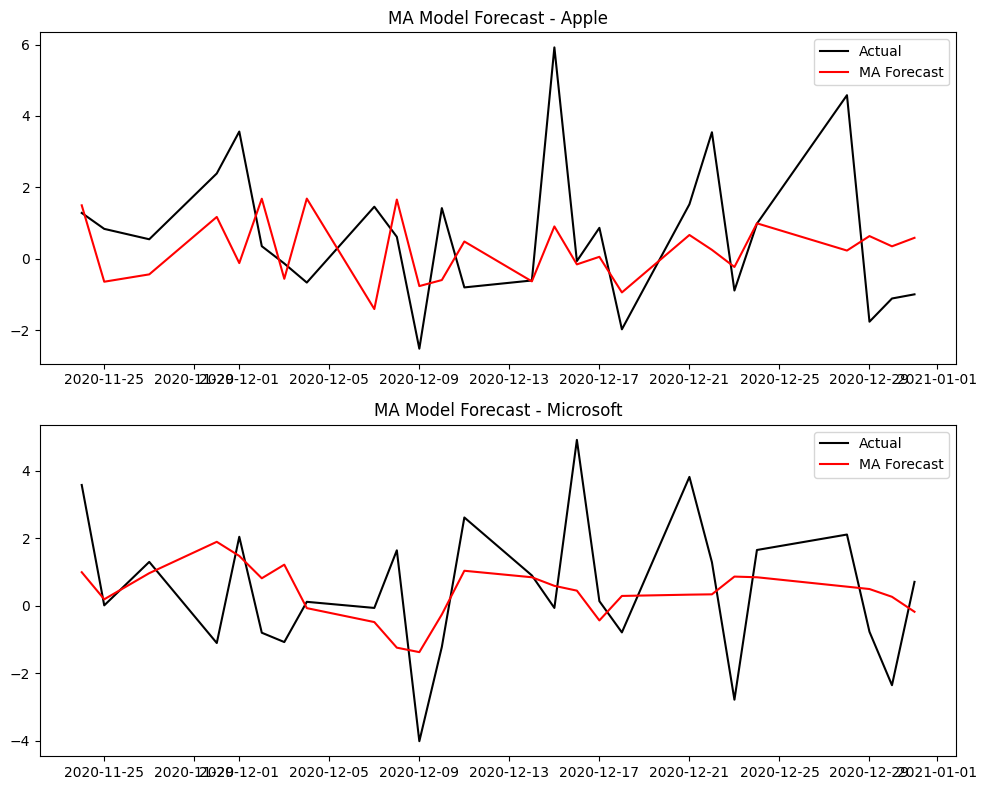

In [ ]:
# ---- 8. Plot forecast vs actual ----
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].plot(diff_test_aapl.index, diff_test_aapl.values, label='Actual', color='black')
ax[0].plot(diff_test_aapl.index, forecast_aapl, label='MA Forecast', color='red')
ax[0].set_title('MA Model Forecast - Apple')
ax[0].legend()

ax[1].plot(diff_test_msft.index, diff_test_msft.values, label='Actual', color='black')
ax[1].plot(diff_test_msft.index, forecast_msft, label='MA Forecast', color='red')
ax[1].set_title('MA Model Forecast - Microsoft')
ax[1].legend()

plt.tight_layout()
plt.savefig('images/ma_forecast.png')
plt.show()


### Recurrent Neural Network (RNN) to do forecasting

In [ ]:
"""
RNN (LSTM-based) forecasting pipeline for AAPL / MSFT RAW stock price levels.

Unlike the ARIMA/MA workflow, we do NOT difference the series here: an
LSTM's gating mechanism can learn trend and level directly from raw
(scaled) prices, so differencing is unnecessary and would just make the
errors/predictions harder to interpret (day-over-day change instead of
actual price).

Pipeline:
  1. Fetch data from Yahoo Finance
  2. Train/test split on raw price levels
  3. Scale (MinMaxScaler, fit on train only) + build sliding-window
     sequences (n_steps=14, features=1)
  4. Hyperparameter tuning with Keras Tuner (units, dropout rate, learning rate, layers)
  5. Train best model with Dropout, BatchNormalization, and EarlyStopping
  6. Evaluate on the held-out test set (RMSE, MAE, in $) and plot predictions vs actuals

Install requirements (if not already installed):
    pip install tensorflow keras-tuner yfinance scikit-learn matplotlib
"""


"\nRNN (LSTM-based) forecasting pipeline for AAPL / MSFT RAW stock price levels.\n \nUnlike the ARIMA/MA workflow, we do NOT difference the series here: an\nLSTM's gating mechanism can learn trend and level directly from raw\n(scaled) prices, so differencing is unnecessary and would just make the\nerrors/predictions harder to interpret (day-over-day change instead of\nactual price).\n \nPipeline:\n  1. Fetch data from Yahoo Finance\n  2. Train/test split on raw price levels\n  3. Scale (MinMaxScaler, fit on train only) + build sliding-window\n     sequences (n_steps=14, features=1)\n  4. Hyperparameter tuning with Keras Tuner (units, dropout rate, learning rate, layers)\n  5. Train best model with Dropout, BatchNormalization, and EarlyStopping\n  6. Evaluate on the held-out test set (RMSE, MAE, in $) and plot predictions vs actuals\n \nInstall requirements (if not already installed):\n    pip install tensorflow keras-tuner yfinance scikit-learn matplotlib\n"

In [ ]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.9 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

In [ ]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("images", exist_ok=True)
os.makedirs("models", exist_ok=True)



In [ ]:

# =====================================================================
# 1. Fetch data
# =====================================================================
ticker = ["AAPL", "MSFT"]
start = datetime.datetime(2019, 1, 1)
end = datetime.datetime(2021, 1, 1)

stock_prices = yf.download(ticker, start=start, end=end, interval="1d").Close
stock_prices = stock_prices.dropna()


/tmp/ipykernel_976/4254263999.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_prices = yf.download(ticker, start=start, end=end, interval="1d").Close
[*********************100%***********************]  2 of 2 completed


In [ ]:
stock_prices

Ticker,AAPL,MSFT
Date,,
2019-01-02,37.436916,94.016190
2019-01-03,33.707924,90.557480
2019-01-04,35.146900,94.769226
2019-01-07,35.068661,94.890091
2019-01-08,35.737179,95.578140
...,...,...
2020-12-24,128.117783,212.390030
2020-12-28,132.699997,214.497253
2020-12-29,130.933151,213.724945


In [ ]:
# =====================================================================
# 2. Train/test split on RAW price levels
#    (No differencing here: unlike ARIMA, an LSTM doesn't need a
#    stationary series -- its gates can learn trend/level directly.
#    We only scale, via MinMaxScaler fit on the training data.)
# =====================================================================
split = int(len(stock_prices["AAPL"].values) * 0.80)

train_aapl = stock_prices["AAPL"].iloc[:split]
test_aapl = stock_prices["AAPL"].iloc[split:]
train_msft = stock_prices["MSFT"].iloc[:split]
test_msft = stock_prices["MSFT"].iloc[split:]


# =====================================================================
# 3. Helper functions: scaling + sliding-window sequence builder
# =====================================================================
N_STEPS = 14
N_FEATURES = 1
BATCH_SIZE = 32


def make_sequences(series_scaled, n_steps):
    """Turn a 1D scaled array into (X, y) sliding-window supervised pairs."""
    X, y = [], []
    for i in range(len(series_scaled) - n_steps):
        X.append(series_scaled[i:i + n_steps])
        y.append(series_scaled[i + n_steps])
    X = np.array(X).reshape(-1, n_steps, N_FEATURES)
    y = np.array(y)
    return X, y


def prepare_data(train_series, test_series, n_steps=N_STEPS, val_fraction=0.15):
    """
    Scales on TRAIN ONLY (avoids leakage), builds sequences, and carves out
    a validation slice from the tail of the training sequences for
    early stopping / tuning.
    """
    # (0, 1) range is the conventional choice for price-level data feeding
    # into an LSTM with a linear output layer.
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_vals = train_series.values.reshape(-1, 1)
    test_vals = test_series.values.reshape(-1, 1)

    train_scaled = scaler.fit_transform(train_vals).flatten()
    test_scaled = scaler.transform(test_vals).flatten()

    # To forecast the first test points with n_steps of history, prepend
    # the tail of the (scaled) training series to the test series.
    test_scaled_with_context = np.concatenate([train_scaled[-n_steps:], test_scaled])

    X_train_full, y_train_full = make_sequences(train_scaled, n_steps)
    X_test, y_test = make_sequences(test_scaled_with_context, n_steps)

    val_size = int(len(X_train_full) * val_fraction)
    X_train, y_train = X_train_full[:-val_size], y_train_full[:-val_size]
    X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]

    return {
        "scaler": scaler,
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
    }



In [ ]:
# =====================================================================
# 4. Model builder for Keras Tuner
#    Uses LSTM layers + Dropout + BatchNormalization to fight overfitting
# =====================================================================
def build_model(hp):
    n_layers = hp.Int("n_layers", 1, 2)
    units = hp.Choice("units", [16, 32, 64])
    dropout_rate = hp.Float("dropout_rate", 0.1, 0.5, step=0.1)
    l2_reg = hp.Choice("l2_reg", [0.0, 1e-4, 1e-3])
    learning_rate = hp.Choice("learning_rate", [1e-2, 1e-3, 5e-4])

    model = keras.Sequential(name="rnn_forecaster")
    model.add(layers.Input(shape=(N_STEPS, N_FEATURES)))

    for i in range(n_layers):
        return_seq = i < n_layers - 1
        model.add(layers.LSTM(
            units,
            return_sequences=return_seq,
            kernel_regularizer=keras.regularizers.l2(l2_reg),
            recurrent_dropout=0.0,  # recurrent_dropout disables cuDNN; use Dropout layer instead
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(16, activation="relu"))
    model.add(layers.Dropout(dropout_rate / 2))
    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return model




In [ ]:
# =====================================================================
# 5. Tune + train for a given ticker
# =====================================================================
def run_pipeline(train_series, test_series, name):
    print(f"\n{'=' * 60}\nRunning RNN pipeline for {name}\n{'=' * 60}")

    data = prepare_data(train_series, test_series)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
    )

    # ---- Hyperparameter search ----
    tuner = kt.RandomSearch(
        build_model,
        objective="val_loss",
        max_trials=15,
        executions_per_trial=1,
        overwrite=True,
        directory="kt_tuning",
        project_name=f"rnn_{name.lower()}",
        seed=SEED,
    )

    tuner.search(
        data["X_train"], data["y_train"],
        validation_data=(data["X_val"], data["y_val"]),
        epochs=60,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0,
    )

    best_hp = tuner.get_best_hyperparameters(1)[0]
    print(f"Best hyperparameters for {name}: {best_hp.values}")

    # ---- Final training run with best hyperparameters ----
    model = tuner.hypermodel.build(best_hp)
    history = model.fit(
        data["X_train"], data["y_train"],
        validation_data=(data["X_val"], data["y_val"]),
        epochs=150,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )

    model.save(f"models/rnn_{name.lower()}.keras")

    # ---- Evaluate on test set ----
    y_pred_scaled = model.predict(data["X_test"]).flatten()
    y_pred = data["scaler"].inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = data["scaler"].inverse_transform(data["y_test"].reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Naive baseline: "tomorrow = today" (shift y_true by 1)
    naive_pred = np.roll(y_true, 1)
    naive_pred[0] = y_true[0]  # can't shift the first point, ignore its error
    naive_rmse = np.sqrt(mean_squared_error(y_true[1:], naive_pred[1:]))
    naive_mae = mean_absolute_error(y_true[1:], naive_pred[1:])

    print(f"{name} - Test RMSE: {rmse:.4f}, Test MAE: {mae:.4f}, Test MAPE: {mape:.2f}%")
    print(f"{name} - Naive baseline RMSE: {naive_rmse:.4f}, MAE: {naive_mae:.4f}")
    if rmse >= naive_rmse:
        print(f"  ⚠ {name} model is NOT beating the naive persistence baseline.")

    # ---- Plot training curves (loss) to visually check overfitting ----
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history["loss"], label="train_loss")
    ax[0].plot(history.history["val_loss"], label="val_loss")
    ax[0].set_title(f"{name} - Loss (MSE)")
    ax[0].legend()

    ax[1].plot(y_true, label="Actual", color="black")
    ax[1].plot(y_pred, label="Predicted", color="red")
    ax[1].set_title(f"{name} - Test Predictions vs Actual")
    ax[1].legend()

    plt.tight_layout()
    plt.savefig(f"images/rnn_{name.lower()}_results.png")
    plt.show()

    return {
        "model": model,
        "history": history,
        "rmse": rmse,
        "mae": mae,
        "y_true": y_true,
        "y_pred": y_pred,
        "best_hp": best_hp.values,
    }





Running RNN pipeline for AAPL
Best hyperparameters for AAPL: {'n_layers': 2, 'units': 32, 'dropout_rate': 0.5, 'l2_reg': 0.0, 'learning_rate': 0.0005}
Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 3.1200 - mae: 1.3291 - val_loss: 0.5143 - val_mae: 0.7081 - learning_rate: 5.0000e-04
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.9835 - mae: 1.0540 - val_loss: 0.4821 - val_mae: 0.6856 - learning_rate: 5.0000e-04
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.7155 - mae: 0.9988 - val_loss: 0.4472 - val_mae: 0.6602 - learning_rate: 5.0000e-04
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.5194 - mae: 0.8796 - val_loss: 0.4390 - val_mae: 0.6545 - learning_rate: 5.0000e-04
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2919 - mae: 0.8147 - val_loss: 0.4358 - val_mae: 0.6521 - learning_rate: 5.0000e-04
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.3723 - mae: 0.8694 - val_loss: 0.4510 - val_mae: 0.6636 

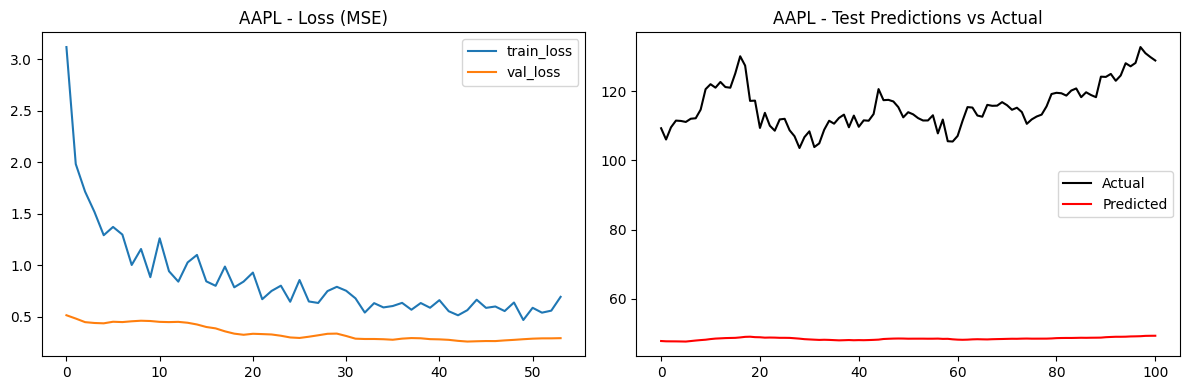


Running RNN pipeline for MSFT
Best hyperparameters for MSFT: {'n_layers': 1, 'units': 32, 'dropout_rate': 0.30000000000000004, 'l2_reg': 0.0, 'learning_rate': 0.001}
Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.3807 - mae: 0.4692 - val_loss: 0.5253 - val_mae: 0.7200 - learning_rate: 0.0010
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1555 - mae: 0.3243 - val_loss: 0.5306 - val_mae: 0.7234 - learning_rate: 0.0010
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1942 - mae: 0.3377 - val_loss: 0.5104 - val_mae: 0.7092 - learning_rate: 0.0010
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1277 - mae: 0.2833 - val_loss: 0.5221 - val_mae: 0.7174 - learning_rate: 0.0010
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1045 - mae: 0.2625 - val_loss: 0.5196 - val_mae: 0.7154 - learning_rate: 0.0010
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0847 - mae: 0.2278 - val_loss: 0.4841 - val_mae: 0.6896 - lea

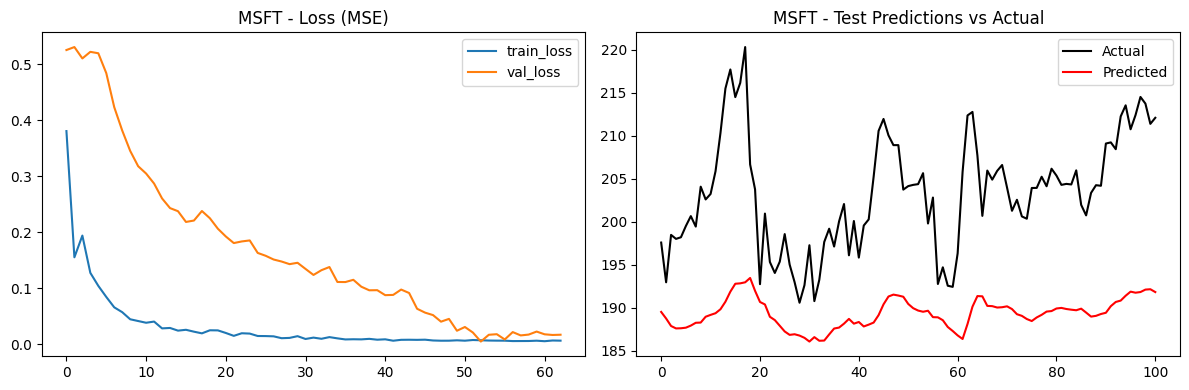


Final summary (errors are in raw price $ units):
AAPL - RMSE: 67.2921, MAE: 66.9965
MSFT - RMSE: 14.9637, MAE: 13.9353

AAPL best hyperparameters: {'n_layers': 2, 'units': 32, 'dropout_rate': 0.5, 'l2_reg': 0.0, 'learning_rate': 0.0005}
MSFT best hyperparameters: {'n_layers': 1, 'units': 32, 'dropout_rate': 0.30000000000000004, 'l2_reg': 0.0, 'learning_rate': 0.001}


In [ ]:
# =====================================================================
# 6. Run for both tickers
# =====================================================================
if __name__ == "__main__":
    results_aapl = run_pipeline(train_aapl, test_aapl, "AAPL")
    results_msft = run_pipeline(train_msft, test_msft, "MSFT")

    print("\nFinal summary (errors are in raw price $ units):")
    print(f"AAPL - RMSE: {results_aapl['rmse']:.4f}, MAE: {results_aapl['mae']:.4f}")
    print(f"MSFT - RMSE: {results_msft['rmse']:.4f}, MAE: {results_msft['mae']:.4f}")
    print(f"\nAAPL best hyperparameters: {results_aapl['best_hp']}")
    print(f"MSFT best hyperparameters: {results_msft['best_hp']}")




## Machine	Learning Based	Volatility	Prediction

In [3]:
import warnings
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore")

In [4]:
# ---------------------------------------------------
# 1. Download S&P 500 data
# ---------------------------------------------------

ticker = "^GSPC"

start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2021, 8, 1)

s_p500 = yf.download(
    ticker,
    start=start,
    end=end,
    interval="1d",
    auto_adjust=False,
    progress=True
)

[*********************100%***********************]  1 of 1 completed


In [5]:
# ---------------------------------------------------
# 2. Calculate daily returns (%)
# ---------------------------------------------------

# Handle possible MultiIndex returned by yfinance
if isinstance(s_p500.columns, pd.MultiIndex):
    adj_close = s_p500["Adj Close"][ticker]
else:
    adj_close = s_p500["Adj Close"]

ret = 100 * adj_close.pct_change(fill_method=None).dropna()

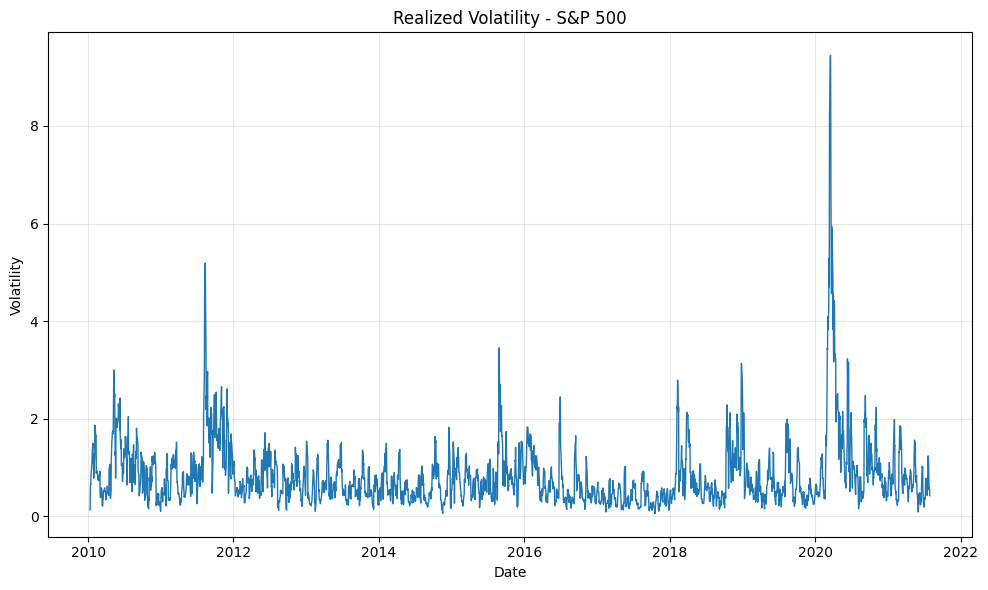

In [7]:

# ---------------------------------------------------
# 3. Calculate 5-day rolling volatility
# ---------------------------------------------------

realized_vol = ret.rolling(window=5).std()


# ---------------------------------------------------
# 4. Plot realized volatility
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    realized_vol.index,
    realized_vol,
    linewidth=1
)

plt.title("Realized Volatility - S&P 500")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig(
    "realized_vol.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ARCH Model

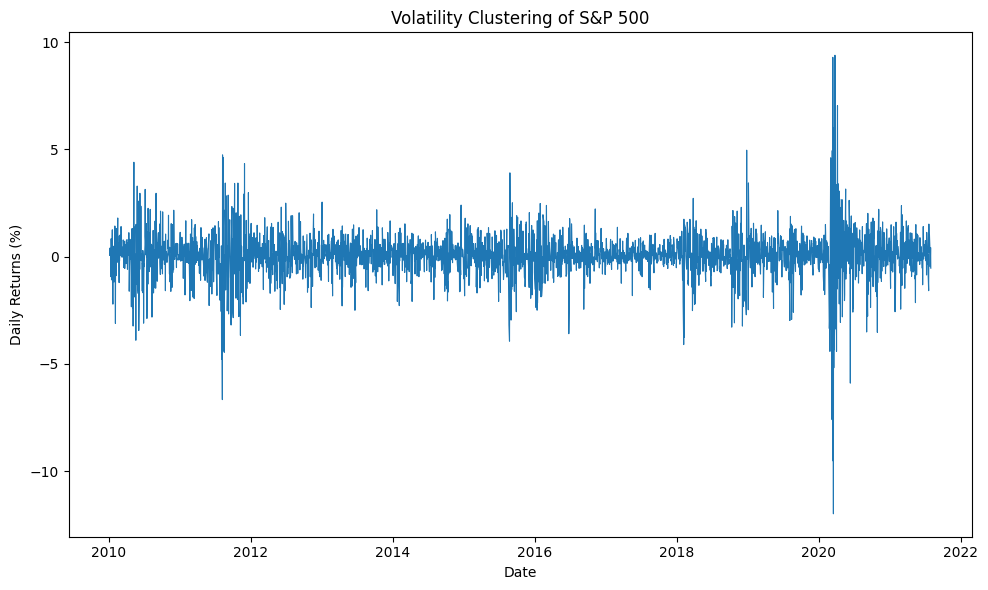

In [ ]:
import os
import matplotlib.pyplot as plt

# Convert returns to NumPy array
retv = ret.values

# Create folder for figures
os.makedirs("images", exist_ok=True)

# Plot daily returns
plt.figure(figsize=(10, 6))

plt.plot(
    ret.index,
    ret,
    linewidth=0.8
)

plt.title("Volatility Clustering of S&P 500")
plt.ylabel("Daily Returns (%)")
plt.xlabel("Date")

plt.tight_layout()

plt.savefig(
    "images/vol_clustering.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [1]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 23.5 MB/s eta 0:00:00


In [ ]:
from arch import arch_model
from sklearn.metrics import mean_squared_error

In [ ]:

# ============================================================
# 1. ARCH model estimation and lag-order selection
#    Compare AIC and BIC for p = 1, 2, 3, 4
# ============================================================

results = []

for p in range(1, 5):

    model = arch_model(
        ret,
        mean="Constant",
        vol="ARCH",
        p=p
    )

    fitted_model = model.fit(disp="off")

    results.append({
        "Lag": p,
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic
    })


In [ ]:
# Convert results to DataFrame
arch_selection = pd.DataFrame(results)

print("\nARCH Lag Selection:")
print(arch_selection.to_string(index=False))


ARCH Lag Selection:
 Lag         AIC         BIC
   1 8097.803683 8115.734499
   2 7598.985985 7622.893740
   3 7474.946832 7504.831526
   4 7388.671340 7424.532973


In [ ]:
# ============================================================
# 2. Select the model
#    Lower AIC/BIC = better
# ============================================================

best_aic_lag = arch_selection.loc[
    arch_selection["AIC"].idxmin(), "Lag"
]

best_bic_lag = arch_selection.loc[
    arch_selection["BIC"].idxmin(), "Lag"
]

print("\nBest lag according to AIC:", int(best_aic_lag))
print("Best lag according to BIC:", int(best_bic_lag))


Best lag according to AIC: 4
Best lag according to BIC: 4


In [ ]:
# ============================================================
# 3. Use BIC-selected lag for final ARCH model
# ============================================================

best_param = int(best_bic_lag)

arch = arch_model(
    ret,
    mean="Constant",
    vol="ARCH",
    p=best_param
).fit(disp="off")

print("\nFinal ARCH Model:")
print(arch.summary())


Final ARCH Model:
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3688.34
Distribution:                  Normal   AIC:                           7388.67
Method:            Maximum Likelihood   BIC:                           7424.53
                                        No. Observations:                 2913
Date:                Tue, Sep 22 2026   Df Residuals:                     2912
Time:                        17:48:55   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0849  1.391e-02      6.103  

In [ ]:
# Use the last 20% of observations as the test period
split_index = int(len(ret) * 0.80)

split_date = ret.index[split_index:]

print("Training observations:", split_index)
print("Testing observations:", len(split_date))
print("Test period:", split_date[0], "to", split_date[-1])

Training observations: 2330
Testing observations: 583
Test period: 2019-04-09 00:00:00 to 2021-07-30 00:00:00


In [ ]:
# ============================================================
# 4. Forecast volatility
# ============================================================

forecast = arch.forecast(
    start=split_date[0],
    horizon=1
)

forecast_arch = forecast


# Extract one-step-ahead forecast variance
forecast_variance = forecast_arch.variance.iloc[:, 0]


# Convert variance to volatility
# ret is measured in percentage units,
# so divide standard deviation by 100
forecast_volatility = np.sqrt(forecast_variance) / 100

In [ ]:
# ============================================================
# 6. Realized volatility for the test period
# ============================================================

realized_vol_test = (
    realized_vol.loc[split_date] / 100
)

forecast_vol_test = (
    forecast_volatility.loc[split_date]
)


# Remove missing observations
comparison = pd.concat(
    [
        realized_vol_test.rename("Realized"),
        forecast_vol_test.rename("Forecast")
    ],
    axis=1
).dropna()


In [ ]:
# ============================================================
# 7. Calculate RMSE
# ============================================================

rmse_arch = np.sqrt(
    mean_squared_error(
        comparison["Realized"],
        comparison["Forecast"]
    )
)

print(
    "\nThe RMSE value of ARCH({}) model is {:.4f}".format(
        best_param,
        rmse_arch
    )
)


The RMSE value of ARCH(4) model is 0.0035


# The RMSE value of ARCH(4) model is 0.0035 (583-step forecast)

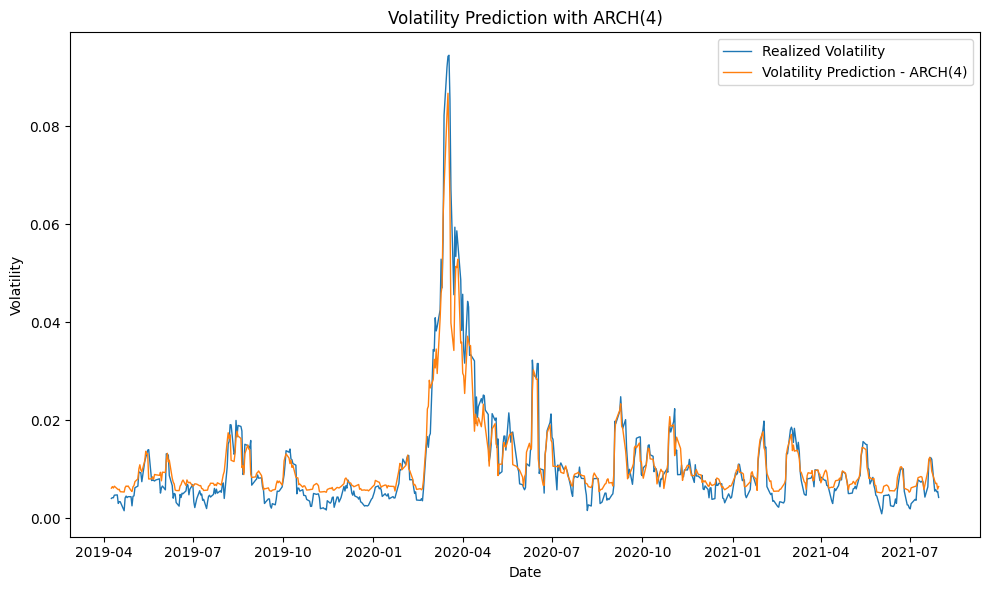

In [ ]:
# ============================================================
# 8. Plot realized vs predicted volatility
# ============================================================

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10, 6))

plt.plot(
    comparison.index,
    comparison["Realized"],
    label="Realized Volatility",
    linewidth=1
)

plt.plot(
    comparison.index,
    comparison["Forecast"],
    label=f"Volatility Prediction - ARCH({best_param})",
    linewidth=1
)

plt.title(
    f"Volatility Prediction with ARCH({best_param})",
    fontsize=12
)

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.tight_layout()

plt.savefig(
    "images/arch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## GARCH Model (RMSE of GARCH(1,1): 0.0042)

## **Recursive one-step forecast**

Training observations: 2330
Testing observations: 583
Test period: 2019-04-09 00:00:00 to 2021-07-30 00:00:00

GARCH Model Selection:
 p  q         AIC         BIC
 1  1 5648.774358 5666.035229
 1  2 5650.774359 5673.788853
 1  3 5652.774358 5681.542476
 1  4 5654.774358 5689.296100
 2  1 5647.775883 5670.790378
 2  2 5647.381981 5676.150099
 2  3 5649.381982 5683.903723
 2  4 5651.381982 5691.657347
 3  1 5649.775884 5678.544001
 3  2 5649.159614 5683.681356
 3  3 5651.159613 5691.434978
 3  4 5653.159613 5699.188602
 4  1 5651.775883 5686.297625
 4  2 5651.103847 5691.379212
 4  3 5653.103848 5699.132836
 4  4 5654.866494 5706.649106

Selected model based on BIC: GARCH(1,1)

RMSE of GARCH(1,1): 0.0042


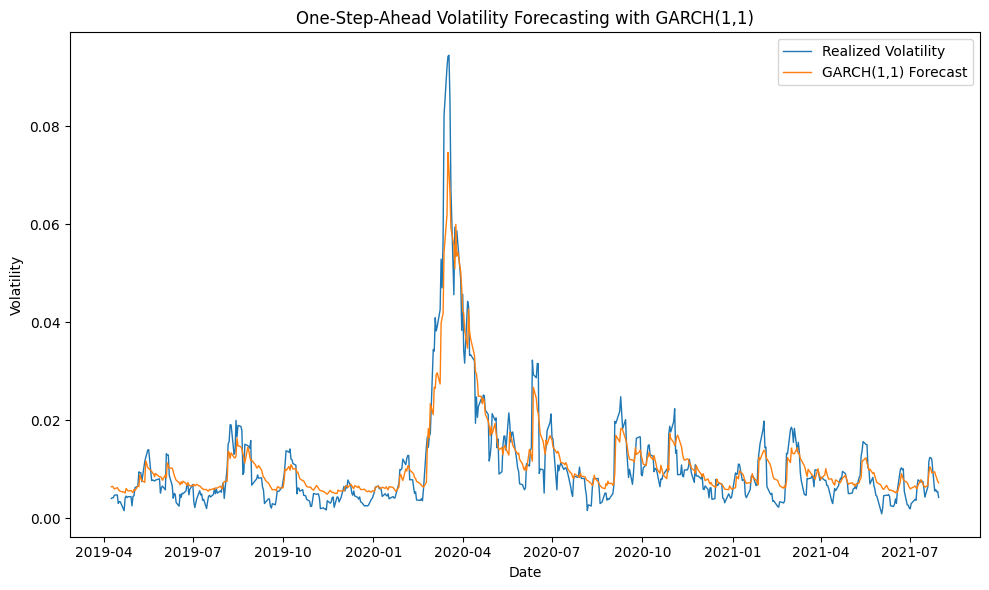

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Train-test split
# ============================================================

split_index = int(len(ret) * 0.80)

train = ret.iloc[:split_index]
test = ret.iloc[split_index:]

split_date = test.index

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Test period:", test.index[0], "to", test.index[-1])


# ============================================================
# 2. Estimate GARCH models on training data
#    Compare AIC and BIC
# ============================================================

results = []

for p in range(1, 5):

    for q in range(1, 5):

        model = arch_model(
            train,
            mean="zero",
            vol="GARCH",
            p=p,
            o=0,
            q=q
        )

        fitted = model.fit(disp="off")

        results.append({
            "p": p,
            "q": q,
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })


garch_selection = pd.DataFrame(results)

print("\nGARCH Model Selection:")
print(garch_selection.to_string(index=False))


# ============================================================
# 3. Select BIC-minimizing model
# ============================================================

best_bic_row = garch_selection.loc[
    garch_selection["BIC"].idxmin()
]

best_p = int(best_bic_row["p"])
best_q = int(best_bic_row["q"])

print(
    f"\nSelected model based on BIC: "
    f"GARCH({best_p},{best_q})"
)


# ============================================================
# 4. Rolling one-step-ahead forecasting
# ============================================================

rolling_forecasts = []

for i in range(len(test)):

    # Expanding training sample:
    # each step adds the most recently observed return
    current_data = ret.iloc[:split_index + i]

    model = arch_model(
        current_data,
        mean="zero",
        vol="GARCH",
        p=best_p,
        o=0,
        q=best_q
    )

    fitted = model.fit(disp="off")


    # One-step-ahead forecast
    forecast = fitted.forecast(
        horizon=1,
        reindex=False
    )

    variance_forecast = forecast.variance.iloc[-1, 0]

    # Convert variance to volatility
    volatility_forecast = np.sqrt(variance_forecast) / 100

    rolling_forecasts.append(volatility_forecast)


# Convert forecasts to Series
forecast_garch = pd.Series(
    rolling_forecasts,
    index=test.index,
    name="GARCH_Forecast"
)


# ============================================================
# 5. Realized volatility
# ============================================================

realized_vol_test = (
    realized_vol.loc[test.index] / 100
)


# Combine
comparison = pd.concat(
    [
        realized_vol_test.rename("Realized"),
        forecast_garch
    ],
    axis=1
).dropna()


# ============================================================
# 6. RMSE
# ============================================================

rmse_garch = np.sqrt(
    mean_squared_error(
        comparison["Realized"],
        comparison["GARCH_Forecast"]
    )
)

print(
    f"\nRMSE of GARCH({best_p},{best_q}): "
    f"{rmse_garch:.4f}"
)


# ============================================================
# 7. Plot
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    comparison.index,
    comparison["Realized"],
    label="Realized Volatility",
    linewidth=1
)

plt.plot(
    comparison.index,
    comparison["GARCH_Forecast"],
    label=f"GARCH({best_p},{best_q}) Forecast",
    linewidth=1
)

plt.title(
    f"One-Step-Ahead Volatility Forecasting with "
    f"GARCH({best_p},{best_q})"
)

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.tight_layout()

plt.savefig(
    "images/garch_rolling_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model EGARCH,  RMSE of EGARCH(1,1,1): 0.005766

Training observations: 2330
Testing observations: 583
Test period: 2019-04-09 00:00:00 to 2021-07-30 00:00:00

EGARCH Model Selection:
 p  q         AIC         BIC
 1  1 5476.091963 5499.106457
 1  2 5478.091963 5506.860081
 1  3 5480.083149 5514.604891
 1  4 5482.083149 5522.358514
 2  1 5473.447972 5502.216090
 2  2 5475.438376 5509.960117
 2  3 5477.071111 5517.346476
 2  4 5479.071111 5525.100099
 3  1 5473.866431 5508.388172
 3  2 5475.866118 5516.141483
 3  3 5477.062893 5523.091881
 3  4 5479.062894 5530.845506
 4  1 5472.674198 5512.949563
 4  2 5474.617864 5520.646852
 4  3 5475.615060 5527.397671
 4  4 5477.603940 5535.140176

Selected model based on BIC: EGARCH(1,1,1)

FINAL EGARCH MODEL SUMMARY
                       Zero Mean - EGARCH Model Results                       
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Li

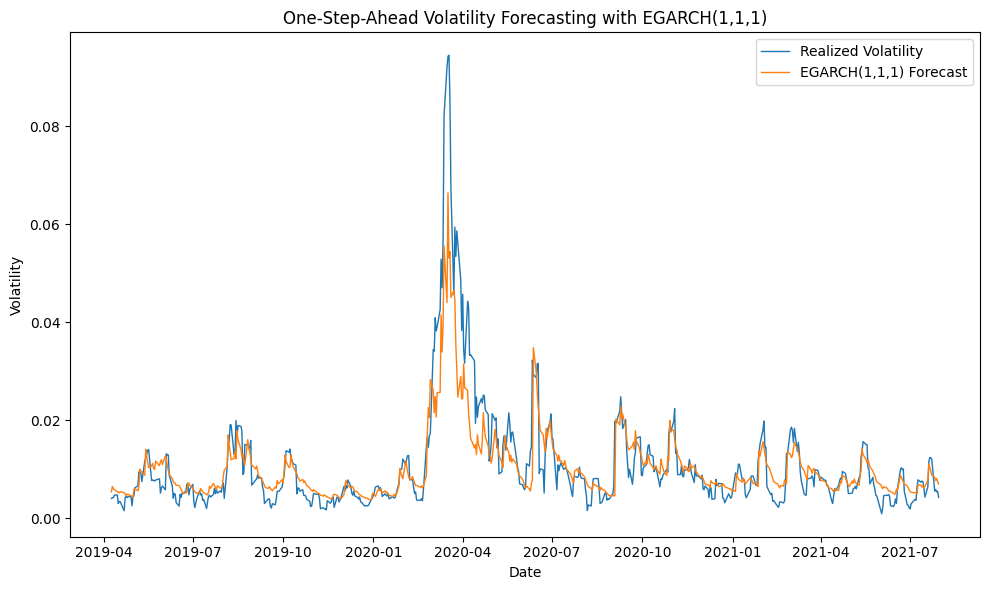

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Train-test split
# ============================================================

split_index = int(len(ret) * 0.80)

train = ret.iloc[:split_index]
test = ret.iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Test period:", test.index[0], "to", test.index[-1])


# ============================================================
# 2. EGARCH Model Selection
#    Compare AIC and BIC
# ============================================================

results = []

for p in range(1, 5):

    for q in range(1, 5):

        model = arch_model(
            train,
            mean="zero",
            vol="EGARCH",
            p=p,
            o=1,
            q=q
        )

        fitted = model.fit(disp="off")

        results.append({
            "p": p,
            "q": q,
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })


egarch_selection = pd.DataFrame(results)

print("\nEGARCH Model Selection:")
print(egarch_selection.to_string(index=False))


# ============================================================
# 3. Select BIC-minimizing model
# ============================================================

best_bic_row = egarch_selection.loc[
    egarch_selection["BIC"].idxmin()
]

best_p = int(best_bic_row["p"])
best_q = int(best_bic_row["q"])

print(
    f"\nSelected model based on BIC: "
    f"EGARCH({best_p},1,{best_q})"
)


# ============================================================
# 4. MAIN MODEL SUMMARY
# ============================================================
# Fit the selected EGARCH model on the training data
# This is the model used for the forecasting exercise.

final_model = arch_model(
    train,
    mean="zero",
    vol="EGARCH",
    p=best_p,
    o=1,
    q=best_q
)

final_fit = final_model.fit(disp="off")

print("\n" + "=" * 70)
print("FINAL EGARCH MODEL SUMMARY")
print("=" * 70)

print(final_fit.summary())


# ============================================================
# 5. Rolling one-step-ahead forecasting
# ============================================================

rolling_forecasts = []

for i in range(len(test)):

    # Expanding training sample
    current_data = ret.iloc[:split_index + i]

    model = arch_model(
        current_data,
        mean="zero",
        vol="EGARCH",
        p=best_p,
        o=1,
        q=best_q
    )

    fitted = model.fit(disp="off")

    # One-step-ahead forecast
    forecast = fitted.forecast(
        horizon=1,
        reindex=False
    )

    variance_forecast = forecast.variance.iloc[-1, 0]

    # Convert variance to volatility
    volatility_forecast = np.sqrt(variance_forecast) / 100

    rolling_forecasts.append(volatility_forecast)


# Convert forecasts to Series
forecast_egarch = pd.Series(
    rolling_forecasts,
    index=test.index,
    name="EGARCH_Forecast"
)


# ============================================================
# 6. Realized volatility
# ============================================================

realized_vol_test = (
    realized_vol.loc[test.index] / 100
)


comparison = pd.concat(
    [
        realized_vol_test.rename("Realized"),
        forecast_egarch
    ],
    axis=1
).dropna()


# ============================================================
# 7. RMSE
# ============================================================

rmse_egarch = np.sqrt(
    mean_squared_error(
        comparison["Realized"],
        comparison["EGARCH_Forecast"]
    )
)

print(
    f"\nRMSE of EGARCH({best_p},1,{best_q}): "
    f"{rmse_egarch:.6f}"
)


# ============================================================
# 8. Plot
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    comparison.index,
    comparison["Realized"],
    label="Realized Volatility",
    linewidth=1
)

plt.plot(
    comparison.index,
    comparison["EGARCH_Forecast"],
    label=f"EGARCH({best_p},1,{best_q}) Forecast",
    linewidth=1
)

plt.title(
    f"One-Step-Ahead Volatility Forecasting with "
    f"EGARCH({best_p},1,{best_q})"
)

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.tight_layout()
plt.show()